Loading data from cache...
Loading data from cache...
===== MS-AR Return Prediction =====
Best config:
{'k_regimes': 2, 'order': 1, 'switching_variance': True, 'trend': 'c', 'switching_ar': False}

Tuning table:
   k_regimes  order  switching_variance          aic          bic  \
0          2      1                True -6434.024477 -6399.315338   
1          2      2                True -6427.572270 -6387.912291   
2          2      1               False -6127.246843 -6097.496152   
3          2      2               False -6006.788175 -5972.085694   

           llf error  
0  3224.012238  None  
1  3221.786135  None  
2  3069.623421  None  
3  3010.394088  None  

Validation metrics:
{'MSE': 5.733694275777382e-05, 'MAE': 0.005959213766283605, 'RMSE': 0.007572116134725736, 'Directional_Accuracy': 0.5530973451327433}

Regime persistence metrics:
   regime     p_ii  expected_duration
0       0  0.97772          44.884170
1       1  0.95070          20.284008

Regime interpretability metr

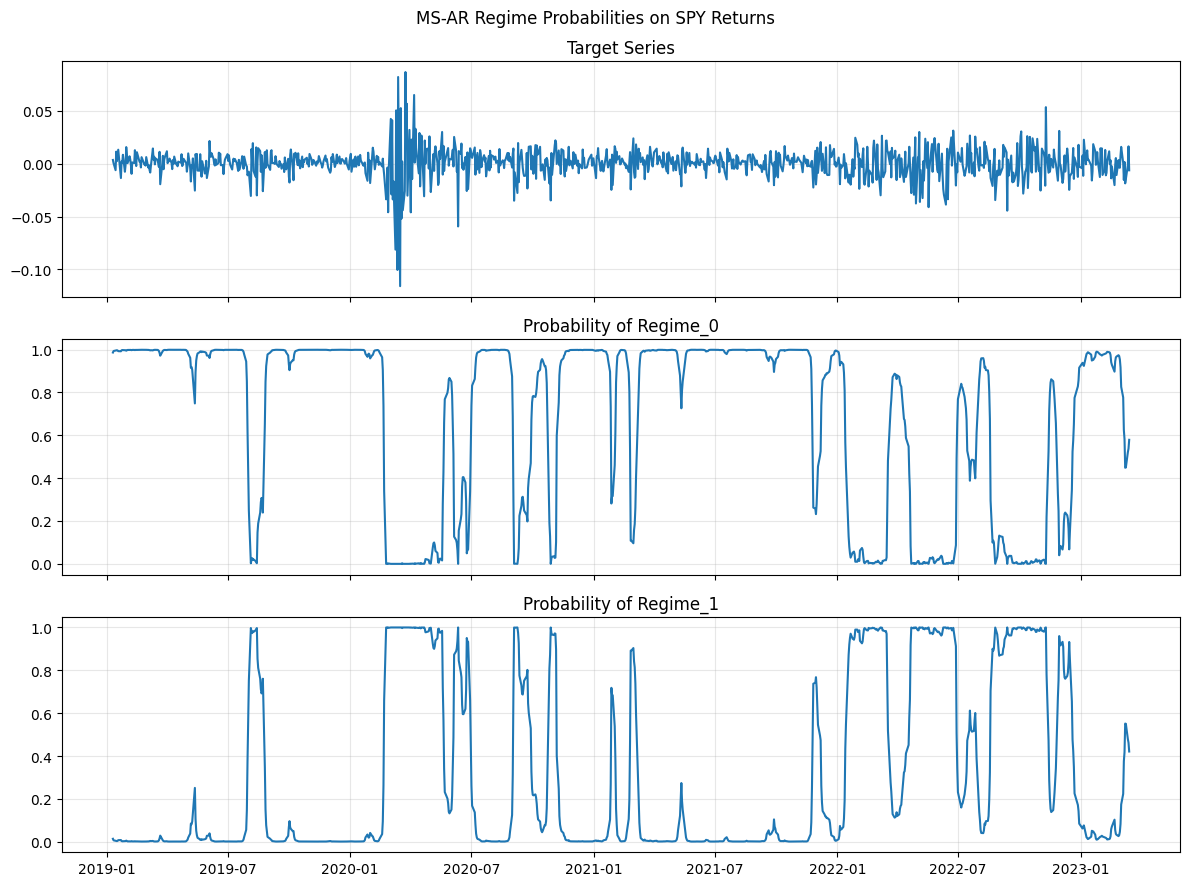



===== MS-AR Realized Volatility Prediction =====
Best config:
{'k_regimes': 2, 'order': 2, 'switching_variance': True, 'trend': 'c', 'switching_ar': False}

Tuning table:
   k_regimes  order  switching_variance         aic         bic         llf  \
0          2      2                True  182.398113  222.058092  -83.199057   
1          2      1               False  238.104800  267.855490 -113.052400   
2          2      1                True  233.622367  268.331506 -109.811184   
3          2      2               False  236.053935  270.756417 -111.026968   

  error  
0  None  
1  None  
2  None  
3  None  

Validation metrics:
{'MSE': 16.926374382918016, 'MAE': 4.1045637803634545, 'RMSE': 4.11416752003586}

Regime persistence metrics:
   regime      p_ii  expected_duration
0       0  0.429503           1.752859
1       1  0.476885           1.911626

Regime interpretability metrics:
   regime  target  n_obs  mean_target  std_target
0       0  log_rv    614     -4.66253    0.654034

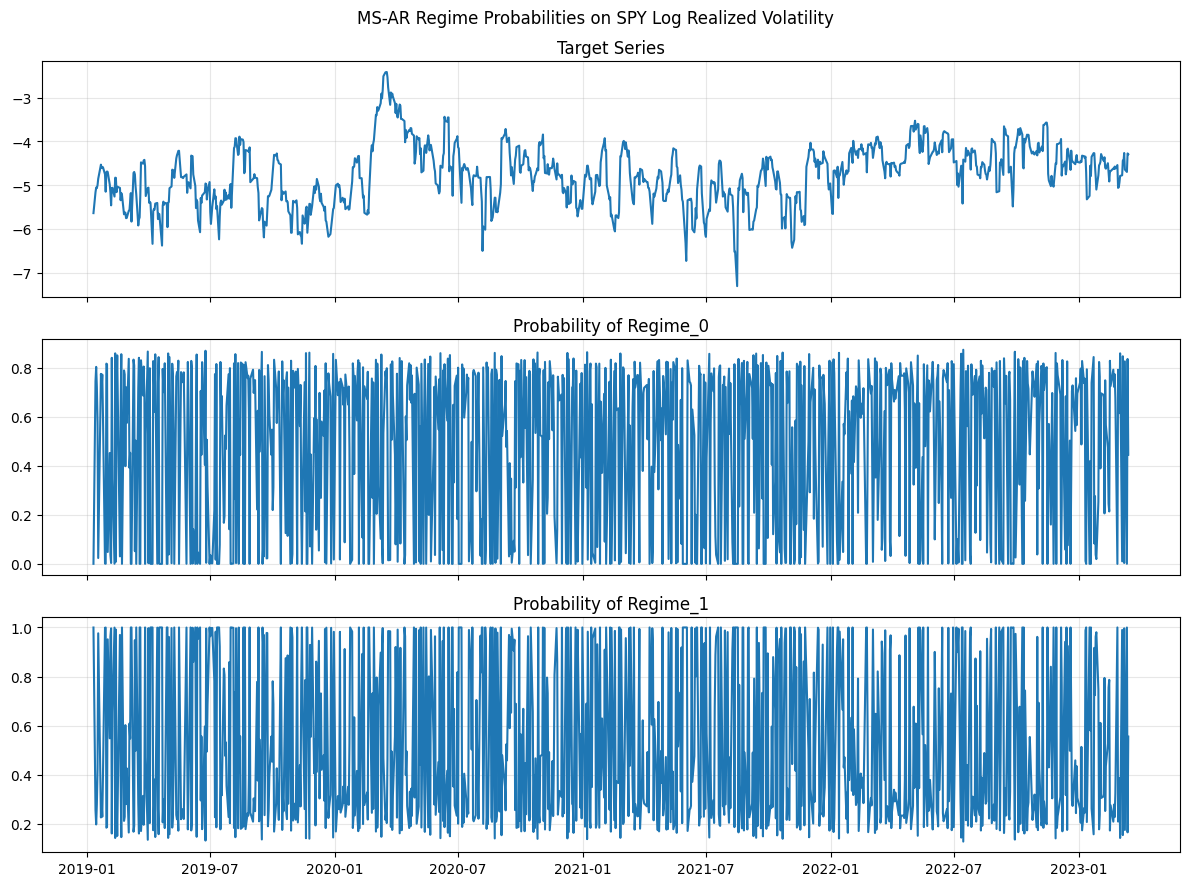


Comparison table:
                      Return MS-AR  Log RV MS-AR
MSE                       0.000057     16.926374
MAE                       0.005959      4.104564
RMSE                      0.007572      4.114168
Directional_Accuracy      0.553097           NaN


In [3]:
from model_utils import MSARConfig, run_full_msar_pipeline, plot_regime_probabilities
import pandas as pd

config = MSARConfig(
    ticker="SPY",
    start_date="2019-01-01",
    end_date="2025-01-01",
    train_ratio=0.7,
    val_ratio=0.15,
    k_regimes=2,
    order=1,
    trend="c",
    rv_window=5,
)

outputs_return = run_full_msar_pipeline(config, target_col="return")
outputs_rv = run_full_msar_pipeline(config, target_col="log_rv")

print("===== MS-AR Return Prediction =====")
print("Best config:")
print(outputs_return["best_config"])
print("\nTuning table:")
print(outputs_return["tuning_table"])
print("\nValidation metrics:")
print(outputs_return["validation_metrics"])
print("\nRegime persistence metrics:")
print(outputs_return["regime_persistence_metrics"])
print("\nRegime interpretability metrics:")
print(outputs_return["regime_interpretability_metrics"])
print("\nStress alignment metrics:")
print(outputs_return["regime_stress_alignment_metrics"])

plot_regime_probabilities(
    outputs_return["best_result"],
    outputs_return["train"]["return"],
    title="MS-AR Regime Probabilities on SPY Returns",
)

print("\n" + "=" * 70 + "\n")

print("===== MS-AR Realized Volatility Prediction =====")
print("Best config:")
print(outputs_rv["best_config"])
print("\nTuning table:")
print(outputs_rv["tuning_table"])
print("\nValidation metrics:")
print(outputs_rv["validation_metrics"])
print("\nRegime persistence metrics:")
print(outputs_rv["regime_persistence_metrics"])
print("\nRegime interpretability metrics:")
print(outputs_rv["regime_interpretability_metrics"])
print("\nStress alignment metrics:")
print(outputs_rv["regime_stress_alignment_metrics"])

plot_regime_probabilities(
    outputs_rv["best_result"],
    outputs_rv["train"]["log_rv"],
    title="MS-AR Regime Probabilities on SPY Log Realized Volatility",
)

comparison = pd.DataFrame({
    "Return MS-AR": outputs_return["validation_metrics"],
    "Log RV MS-AR": outputs_rv["validation_metrics"],
})
print("\nComparison table:")
print(comparison)
